# Install the Libraries

In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import os # to interact with the operating system
import matplotlib.pyplot as plt
import seaborn as sns

# Data Analysis

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/Kani722/Laptop-Price-Predictor/main/model/laptop_price.csv"
data = pd.read_csv(url, encoding='latin-1')

data.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


# No. of Rows & Columns

In [4]:
data.shape

(1303, 13)

# Find Missing Values or Null Values

In [5]:
data.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

# Description of the Columns

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


# Data Cleaning

In [7]:
data['Ram'] = data['Ram'].str.replace('GB','').astype('int32')
data['Weight'] = data['Weight'].str.replace('kg','').astype('float32')

In [8]:
data.head(3)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00


# Find dependent or independent variable

In [9]:
numeric_data = data.select_dtypes(include=['number'])
correlations = numeric_data.corr()['Price_euros']
print(correlations)

laptop_ID      0.067830
Inches         0.068197
Ram            0.743007
Weight         0.210370
Price_euros    1.000000
Name: Price_euros, dtype: float64


# Find the Outliers

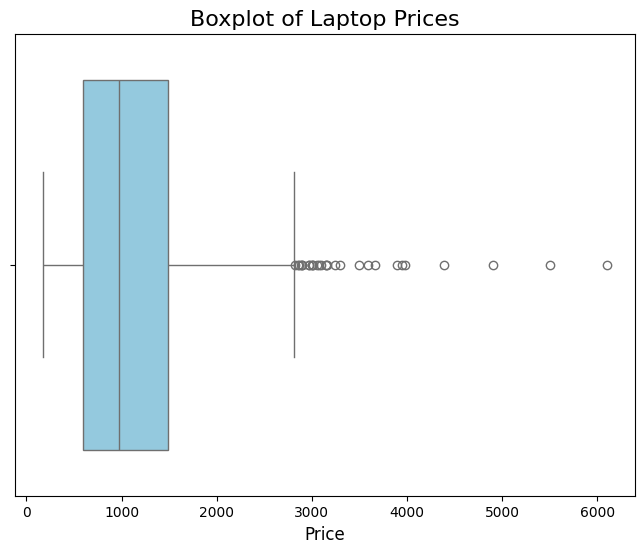

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Price_euros'], color='skyblue')
plt.title("Boxplot of Laptop Prices", fontsize=16)
plt.xlabel("Price", fontsize=12)
plt.show()

# Remove the outliers

Data shape after removing outliers: (1274, 13)


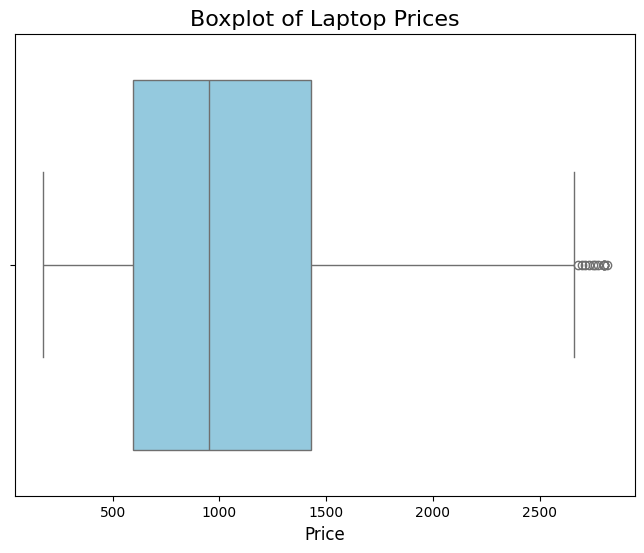

In [11]:
Q1 = data['Price_euros'].quantile(0.25)  # First quartile
Q3 = data['Price_euros'].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
data = data[(data['Price_euros'] >= lower_bound) & (data['Price_euros'] <= upper_bound)]
print(f"Data shape after removing outliers: {data.shape}")

plt.figure(figsize=(8, 6))
sns.boxplot(x=data['Price_euros'], color='skyblue')
plt.title("Boxplot of Laptop Prices", fontsize=16)
plt.xlabel("Price", fontsize=12)
plt.show()

# Split dataset by Company

In [12]:
data['Company'].value_counts()

Company
Lenovo       291
Dell         287
HP           270
Asus         154
Acer         103
MSI           54
Toshiba       48
Apple         20
Samsung        9
Mediacom       7
Microsoft      6
Vero           4
Xiaomi         4
Google         3
Chuwi          3
Razer          3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

In [13]:
len(data['Company'].value_counts())

19

# Categorize data by company

In [14]:
def add_company(inpt):
    if inpt == 'Samsung' or inpt == 'Razer' or inpt == 'Mediacom' or inpt == 'Microsoft'or inpt == 'Xiaomi'or inpt == 'Vero'or inpt == 'Chuwi'or inpt == 'Google'or inpt == 'Fujitsu'or inpt == 'LG'or inpt == 'Huawei':
        return 'Other'
    else:
        return inpt
data['Company'] = data['Company'].apply(add_company)

In [15]:
data['Company'].value_counts()

Company
Lenovo     291
Dell       287
HP         270
Asus       154
Acer       103
MSI         54
Toshiba     48
Other       47
Apple       20
Name: count, dtype: int64

# Split dataset by Product

In [16]:
data['Product'].value_counts()

Product
XPS 13                                 30
Inspiron 3567                          29
250 G6                                 21
Legion Y520-15IKBN                     19
Vostro 3568                            19
                                       ..
Aspire A515-51G-32MX                    1
Pavilion 15-CK000nv                     1
V110-15ISK (i3-6006U/4GB/1TB/Radeon     1
Rog G752VY-GC229T                       1
GS73VR 7RF                              1
Name: count, Length: 607, dtype: int64

In [17]:
len(data['Product'].value_counts())

607

# Split dataset by TypeName

In [18]:
data['TypeName'].value_counts()

TypeName
Notebook              724
Ultrabook             194
Gaming                188
2 in 1 Convertible    120
Netbook                25
Workstation            23
Name: count, dtype: int64

In [19]:
len(data['TypeName'].value_counts())

6

# Split dataset by ScreenResolution

In [20]:
data['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                501
1366x768                                         281
IPS Panel Full HD 1920x1080                      220
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160                7
IPS Panel 1366x768                                 7
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2560x1440                              6
IPS Panel 4K Ultra HD 3840x2160                    6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
4K Ultra HD 3840x2160                              5
IPS Panel Touchscreen 2560x14

In [21]:
len(data['ScreenResolution'].value_counts())

40

# Divide ScreenResolution column to two columns

In [22]:
data['Touchscreen'] = data['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
data['Ips'] = data['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [23]:
data.head(4)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,0,0
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1


# Split dataset by Cpu

In [24]:
data['Cpu'].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       190
Intel Core i7 7700HQ 2.8GHz      134
Intel Core i7 7500U 2.7GHz       133
Intel Core i7 8550U 1.8GHz        73
Intel Core i5 8250U 1.6GHz        72
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 115, dtype: int64

In [25]:
len(data['Cpu'].value_counts())

115

In [26]:
data.head(2)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0


# Create new Column to update the Cpu

In [27]:
data['Cpu_Name'] = data['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

# Split dataset by Cpu_Name(New)

In [28]:
data['Cpu_Name'].value_counts()

Cpu_Name
Intel Core i7               502
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 18
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
Intel Atom x5-Z8550           4
AMD A8-Series 7410            4
Intel Pentium Dual            3
AMD Ryzen 1700                3
AMD A9-Series 9410            3
AMD E-Series E2-9000e         2
AMD A10-Series A10-9620P      2
AMD A10-Series 9600P          2
AMD A10-Series 9620P          2
AMD E-Series 7110             2
AMD A6-Series A6-9220         2
AMD A9-Series A9-9420         2
Intel Atom X5-Z8350           2
AMD E-Series 9000e            1
Intel Atom x5-Z8300           1
AMD FX 9830P                  1
AMD E-Series E2-6110          1
AMD E-Series 6110             1
AMD Ryzen 1600                1
Intel Xeon E3-1505M           1

# Categories the Cpu_Name

In [29]:
def set_processor(name):
    if name == 'Intel Core i7' or name == 'Intel Core i5' or name == 'Intel Core i3':
        return name
    else:
        if name.split()[0] == 'AMD':
            return 'AMD'
        else:
            return 'Other'
data['Cpu_Name'] = data['Cpu_Name'].apply(set_processor)

In [30]:
data['Cpu_Name'].value_counts()

Cpu_Name
Intel Core i7    502
Intel Core i5    423
Other            151
Intel Core i3    136
AMD               62
Name: count, dtype: int64

# Split dataset by Ram

In [31]:
data['Ram'].value_counts()

Ram
8     615
4     375
16    187
6      41
12     25
2      22
32      7
24      2
Name: count, dtype: int64

In [32]:
len(data['Ram'].value_counts())

8

# Split dataset by Gpu

In [33]:
data['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      280
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     46
                          ... 
AMD Radeon R5 M315           1
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 102, dtype: int64

In [34]:
len(data['Gpu'].value_counts())

102

# Categorize GPU data by first word

In [35]:
data['Gpu_Name'] = data['Gpu'].apply(lambda x:" ".join(x.split()[0:1]))
data['Gpu_Name'].value_counts()

Gpu_Name
Intel     720
Nvidia    375
AMD       178
ARM         1
Name: count, dtype: int64

In [36]:
data.shape

(1274, 17)

In [37]:
data.head(4)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips,Cpu_Name,Gpu_Name
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,Intel Core i5,Intel
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,Intel Core i5,Intel
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,0,0,Intel Core i5,Intel
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,Intel Core i7,AMD


# Remove the row of ARM

In [38]:
data = data[data['Gpu_Name'] != 'ARM']

In [39]:
data.shape

(1273, 17)

In [40]:
data.head(4)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips,Cpu_Name,Gpu_Name
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,Intel Core i5,Intel
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,0,0,Intel Core i5,Intel
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,0,0,Intel Core i5,Intel
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,0,1,Intel Core i7,AMD


# Split dataset by OpSys

In [41]:
data['OpSys'].value_counts()

OpSys
Windows 10      1048
No OS             66
Linux             62
Windows 7         41
Chrome OS         26
macOS             12
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [42]:
len(data['OpSys'].value_counts())

9

# Print the unique name of OpSys 

In [43]:
print(data['OpSys'].unique())

['macOS' 'No OS' 'Windows 10' 'Mac OS X' 'Linux' 'Android' 'Windows 10 S'
 'Chrome OS' 'Windows 7']


# Catagorize the OpSys 

In [44]:
def set_os(inpt):
    if inpt == 'Windows 10' or inpt == 'Windows 7' or inpt == 'Windows 10 S':
        return 'Windows'
    elif inpt == 'macOS' or inpt == 'Mac OS X':
        return 'Mac'
    elif inpt == 'Linux':
        return inpt
    else:
        return 'Other'

In [45]:
data['OpSys'] = data['OpSys'].apply(set_os)

In [46]:
data['OpSys'].value_counts()

OpSys
Windows    1097
Other        94
Linux        62
Mac          20
Name: count, dtype: int64

In [47]:
data.head(4)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Touchscreen,Ips,Cpu_Name,Gpu_Name
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,Mac,1.37,1339.69,0,1,Intel Core i5,Intel
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,Mac,1.34,898.94,0,0,Intel Core i5,Intel
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,Other,1.86,575.00,0,0,Intel Core i5,Intel
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,Mac,1.83,2537.45,0,1,Intel Core i7,AMD


# Remove the unnecessary columns

In [48]:
data = data.drop(columns=['laptop_ID', 'Inches', 'Product', 'ScreenResolution', 'Cpu', 'Gpu', 'Memory'])

In [49]:
data.head()

,Company,TypeName,Ram,OpSys,Weight,Price_euros,Touchscreen,Ips,Cpu_Name,Gpu_Name
0,Apple,Ultrabook,8,Mac,1.37,1339.69,0,1,Intel Core i5,Intel
1,Apple,Ultrabook,8,Mac,1.34,898.94,0,0,Intel Core i5,Intel
2,HP,Notebook,8,Other,1.86,575.00,0,0,Intel Core i5,Intel
3,Apple,Ultrabook,16,Mac,1.83,2537.45,0,1,Intel Core i7,AMD
4,Apple,Ultrabook,8,Mac,1.37,1803.60,0,1,Intel Core i5,Intel


# One-Hot Encoding

In [50]:
data = pd.get_dummies(data)

In [51]:
data.head(4)

,Ram,Weight,Price_euros,Touchscreen,Ips,Company_Acer,Company_Apple,Company_Asus,Company_Dell,Company_HP,...,OpSys_Other,OpSys_Windows,Cpu_Name_AMD,Cpu_Name_Intel Core i3,Cpu_Name_Intel Core i5,Cpu_Name_Intel Core i7,Cpu_Name_Other,Gpu_Name_AMD,Gpu_Name_Intel,Gpu_Name_Nvidia
0,8,1.37,1339.69,0,1,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,8,1.34,898.94,0,0,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,8,1.86,575.00,0,0,False,False,False,False,True,...,True,False,False,False,True,False,False,False,True,False
3,16,1.83,2537.45,0,1,False,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [52]:
data.shape

(1273, 32)

# Update the Price_euros name 

In [53]:
data = data.rename(columns={'Price_euros': 'Price_Euros'})

In [54]:
data.head()

,Ram,Weight,Price_Euros,Touchscreen,Ips,Company_Acer,Company_Apple,Company_Asus,Company_Dell,Company_HP,...,OpSys_Other,OpSys_Windows,Cpu_Name_AMD,Cpu_Name_Intel Core i3,Cpu_Name_Intel Core i5,Cpu_Name_Intel Core i7,Cpu_Name_Other,Gpu_Name_AMD,Gpu_Name_Intel,Gpu_Name_Nvidia
0,8,1.37,1339.69,0,1,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,8,1.34,898.94,0,0,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,8,1.86,575.00,0,0,False,False,False,False,True,...,True,False,False,False,True,False,False,False,True,False
3,16,1.83,2537.45,0,1,False,True,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,8,1.37,1803.60,0,1,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False


# Splitting the dataset here as independent variable and dependent variable

In [55]:
X = data.drop('Price_Euros', axis=1)
y = data['Price_Euros']

In [56]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates f

In [57]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Splitting the dataset into training and testing

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [59]:
X_train.shape, X_test.shape

((954, 31), (319, 31))

# Use Random forest regression and training the module

In [60]:
from sklearn.ensemble import RandomForestRegressor
dtree = RandomForestRegressor()
dtree.fit(X_train, y_train)

RandomForestRegressor()

# Predicting the Results

In [61]:
y_pred = dtree.predict(X_test)
y_pred

array([1874.781     ,  752.2334    , 1015.07611   ,  406.61333333,
       1518.16      , 2585.0869    , 1117.58459524, 2004.6746    ,
       1150.590225  ,  520.45278333, 1059.10146667, 2148.51      ,
        520.45278333,  658.75926667, 1070.30926   ,  524.2423    ,
       1358.404     ,  238.656     ,  809.5306    , 1086.2203344 ,
       1405.03      , 1170.82631667, 2387.76      ,  792.518075  ,
        488.09168333, 1681.56      ,  744.88153143,  452.03538869,
        794.38336667,  792.518075  , 1722.87116667,  489.37476667,
        656.369     ,  679.3401    ,  289.7565119 ,  953.24543333,
        368.41940476,  816.63743333,  679.3401    ,  627.135     ,
        489.71642857,  644.43525   , 1103.58761667,  642.81426667,
       1436.74965619,  817.646725  ,  791.32219286,  503.13731381,
        815.72      , 2308.84255   , 1811.917     ,  871.052     ,
       1134.47823212, 1696.07393333, 1684.79586452, 1081.60245667,
       1408.3084    , 2555.18139333, 1944.72183333, 1326.84186

# Finding the R-squared, MSE and accuracy

In [62]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Random Forest Regression MSE: {:.2f}, R-squared: {:.2f}'.format(mse, r2))

Random Forest Regression MSE: 73980.73, R-squared: 0.78


# Use Linear Regression and Decission Tree to find the accuarcy and R-squared

In [63]:
from sklearn.linear_model import LinearRegression          
from sklearn.tree import DecisionTreeRegressor           
from sklearn.metrics import mean_squared_error, r2_score  

lr = LinearRegression()  
lr.fit(X_train, y_train)  

dtt = DecisionTreeRegressor(random_state=42)  
dtt.fit(X_train, y_train)  

lr_predictions = lr.predict(X_test)  
dtt_predictions = dtt.predict(X_test)  

# Calculate Mean Squared Error (MSE) and R-squared for the Linear Regression model
lr_mse = mean_squared_error(y_test, lr_predictions)  
lr_r2 = r2_score(y_test, lr_predictions)  

# Calculate Mean Squared Error (MSE) and R-squared for the Decision Tree Regressor model
dtt_mse = mean_squared_error(y_test, dtt_predictions)  
dtt_r2 = r2_score(y_test, dtt_predictions)  

# Print the evaluation metrics for the Linear Regression model
print('Linear Regression MSE: {:.2f}, R-squared: {:.2f}'.format(lr_mse, lr_r2))  

# Print the evaluation metrics for the Decision Tree Regressor model
print('Decision Tree Regression MSE: {:.2f}, R-squared: {:.2f}'.format(dtt_mse, dtt_r2))  


Linear Regression MSE: 106070.64, R-squared: 0.69
Decision Tree Regression MSE: 102600.02, R-squared: 0.70


# Use hyper parameter tuning on random forest regressor

In [64]:
from sklearn.model_selection import RandomizedSearchCV
# Number of trees in random forest
n_estimators = [200]
# Number of features to consider at every split
max_features = [25]
# Maximum number of levels in tree
max_depth = [100]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [25]
# Minimum number of samples required at each leaf node
min_samples_leaf = [24]
# Method of selecting samples for training each tree
bootstrap = [False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
print(random_grid)

{'n_estimators': [200], 'max_features': [25], 'max_depth': [100, None], 'min_samples_split': [25], 'min_samples_leaf': [24], 'bootstrap': [False]}


In [65]:
rf = RandomForestRegressor()
# Random search of parameters, using 3 fold cross validation, 
# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

C:\Users\HOME\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 2 is smaller than n_iter=100. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 2 candidates, totalling 6 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [False],
                                        'max_depth': [100, None],
                                        'max_features': [25],
                                        'min_samples_leaf': [24],
                                        'min_samples_split': [25],
                                        'n_estimators': [200]},
                   random_state=42, verbose=2)

In [66]:
base_model = RandomForestRegressor(n_estimators = 200, random_state = 42)
base_model.fit(X_train, y_train)
pred = base_model.predict(X_test)
r2 = r2_score(y_test,pred)
print("R2-score:",r2) # R-Squared value after hyper parameter tuning

R2-score: 0.7831994590943252


In [67]:
X_test.columns

Index(['Ram', 'Weight', 'Touchscreen', 'Ips', 'Company_Acer', 'Company_Apple',
       'Company_Asus', 'Company_Dell', 'Company_HP', 'Company_Lenovo',
       'Company_MSI', 'Company_Other', 'Company_Toshiba',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'OpSys_Linux', 'OpSys_Mac', 'OpSys_Other', 'OpSys_Windows',
       'Cpu_Name_AMD', 'Cpu_Name_Intel Core i3', 'Cpu_Name_Intel Core i5',
       'Cpu_Name_Intel Core i7', 'Cpu_Name_Other', 'Gpu_Name_AMD',
       'Gpu_Name_Intel', 'Gpu_Name_Nvidia'],
      dtype='object')

# Save the Model

In [68]:
import pickle
with open('predictorFromRF.pickle', 'wb') as file:
    pickle.dump(base_model, file)

In [69]:
X_train.columns

Index(['Ram', 'Weight', 'Touchscreen', 'Ips', 'Company_Acer', 'Company_Apple',
       'Company_Asus', 'Company_Dell', 'Company_HP', 'Company_Lenovo',
       'Company_MSI', 'Company_Other', 'Company_Toshiba',
       'TypeName_2 in 1 Convertible', 'TypeName_Gaming', 'TypeName_Netbook',
       'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation',
       'OpSys_Linux', 'OpSys_Mac', 'OpSys_Other', 'OpSys_Windows',
       'Cpu_Name_AMD', 'Cpu_Name_Intel Core i3', 'Cpu_Name_Intel Core i5',
       'Cpu_Name_Intel Core i7', 'Cpu_Name_Other', 'Gpu_Name_AMD',
       'Gpu_Name_Intel', 'Gpu_Name_Nvidia'],
      dtype='object')

# Predicted the Price

In [70]:
pred_value = base_model.predict([[8, 1.3, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0]])
pred_value

C:\Users\HOME\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([1575.27770643])

In [71]:
pred_value = base_model.predict([[16, 1.2, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0]])
pred_value

C:\Users\HOME\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([1924.05797])

In [72]:
pred_value = base_model.predict([[8, 1.5, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0]])
pred_value

C:\Users\HOME\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([1702.71682893])